# Exploratory Data Analysis (EDA)
## ML Modeling Challenge - Wizeline

In [31]:
import polars as pl

## 1.Carga de datos

In [32]:
# Datos de entrenamiento
df_train = pl.read_csv("data/training_data.csv")
print(f"Training data shape: {df_train.shape}")
df_train.head()

Training data shape: (800, 21)


feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
432.475954,289.373016,481.3156,358.755566,802.659004,176.761177,72.648102,720.969179,36.327684,83.768878,659.390923,4.385848,516.789458,19.624422,13.16244,42.351948,35.920392,20.755984,13.8143,384.497136,14.364922
517.59625,330.448341,585.920055,22.684031,169.81324,335.60164,284.451476,748.101047,73.701438,358.147215,11.036952,5.563334,2.960064,20.721878,17.740184,1.726915,167.576065,75.492679,2.480979,303.710869,19.984801
189.43935,553.88882,165.83379,202.465927,176.695586,321.155049,407.278389,161.245668,282.269025,221.570899,143.919562,4.536947,581.823741,101.695639,0.653592,486.859084,117.491548,6.420465,20.713314,22.651537,12.944351
237.307878,195.894881,416.752252,468.729031,611.693517,301.411711,241.880655,49.597044,122.396821,13.828319,677.161907,5.518968,45.014729,196.350455,47.638515,411.414213,67.142022,115.630943,8.927957,388.240433,14.79244
602.845256,16.103208,221.759979,345.765574,558.588369,276.704241,408.069566,19.390813,138.769765,146.662193,311.747565,2.136214,133.59043,197.634584,26.278027,111.127557,172.181136,85.869642,30.537857,625.931837,11.802634


In [33]:
# Datos de prueba ciega
df_test = pl.read_csv("data/blind_test_data.csv")
print(f"Blind test data shape: {df_test.shape}")
df_test.head()

Blind test data shape: (200, 20)


feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
676.867615,32.518822,254.825875,502.26851,609.469688,497.624266,105.246239,269.045539,150.177005,312.64986,765.296227,0.237996,660.030637,147.059794,40.232132,464.424834,121.147466,68.284243,26.96987,314.461582
628.695228,426.163933,347.07028,431.106903,915.527507,301.699534,1.666992,306.733041,104.234252,63.24207,467.009734,6.608084,600.994184,43.619815,48.153926,457.256565,49.163652,85.511662,33.500538,819.537877
131.765943,323.839669,245.399775,181.814398,710.179159,59.117377,312.622788,687.965027,109.803179,381.1695,700.532108,1.82237,736.306092,138.759029,36.915389,436.174065,10.037994,62.631938,6.211169,341.361374
160.970195,489.712029,70.482159,309.486269,888.030604,412.655666,216.124989,47.415477,104.139145,326.462385,378.446187,1.686895,485.144327,143.668518,27.168148,309.715497,149.661493,66.415878,15.001753,539.087409
419.907137,216.625219,487.88786,253.704462,323.226862,65.744463,271.811469,527.726782,129.805782,168.429679,637.944633,0.948507,365.946758,72.337904,36.232169,302.772338,186.944884,106.514846,3.443809,364.341969


## 2. Conteo de missing

In [34]:
# Missing values en df_train
df_missing_train = (
    df_train.null_count()
    .unpivot(variable_name="variable", value_name="missing_count")
    .filter(pl.col("missing_count") > 0)
    .sort("missing_count", descending=True)
)
print("Missing values en df_train:")
print(df_missing_train)

Missing values en df_train:
shape: (0, 2)
┌──────────┬───────────────┐
│ variable ┆ missing_count │
│ ---      ┆ ---           │
│ str      ┆ u32           │
╞══════════╪═══════════════╡
└──────────┴───────────────┘


In [35]:
# Missing values en df_test
df_missing_test = (
    df_train.null_count()
    .unpivot(variable_name="variable", value_name="missing_count")
    .filter(pl.col("missing_count") > 0)
    .sort("missing_count", descending=True)
)
print("Missing values en df_train:")
print(df_missing_test)

Missing values en df_train:
shape: (0, 2)
┌──────────┬───────────────┐
│ variable ┆ missing_count │
│ ---      ┆ ---           │
│ str      ┆ u32           │
╞══════════╪═══════════════╡
└──────────┴───────────────┘


## 3. Análisis de la correlación (Spearman)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [37]:
# Calcular la matriz de correlación de Spearman sobre df_train (features + target)
data = df_train.to_numpy()
cols = df_train.columns
corr_matrix, _ = spearmanr(data)
print(f"Matriz de correlación: {corr_matrix.shape}")

Matriz de correlación: (21, 21)


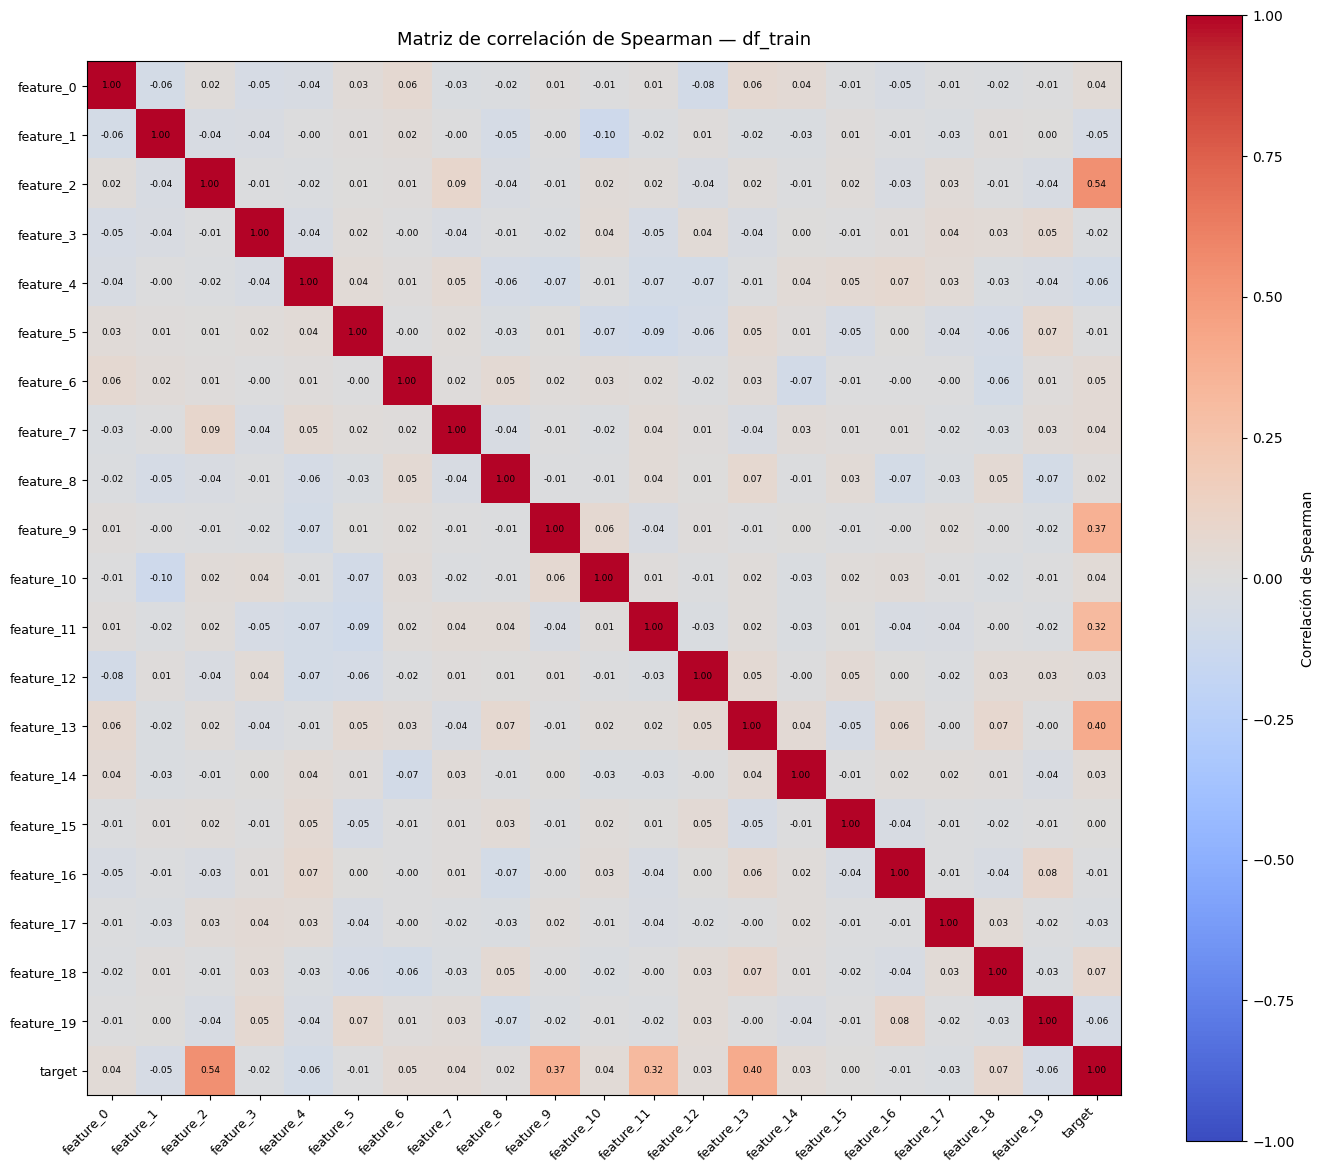

In [38]:
# Heatmap de la matriz de correlación de Spearman
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Correlación de Spearman")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(cols, fontsize=9)

# Anotar valores en cada celda
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center",
                fontsize=6.5, color="black")

ax.set_title("Matriz de correlación de Spearman — df_train", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 4. Información mutua (dependencia lineal y no lineal con target)

In [39]:
from sklearn.feature_selection import mutual_info_regression

feature_cols = [c for c in df_train.columns if c != "target"]
X = df_train.select(feature_cols).to_numpy()
y = df_train["target"].to_numpy()

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = (
    pl.DataFrame({"feature": feature_cols, "mutual_info": mi_scores})
    .sort("mutual_info", descending=True)
)
print(mi_df)

shape: (20, 2)
┌────────────┬─────────────┐
│ feature    ┆ mutual_info │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ feature_2  ┆ 0.183933    │
│ feature_13 ┆ 0.128519    │
│ feature_16 ┆ 0.062835    │
│ feature_9  ┆ 0.053173    │
│ feature_3  ┆ 0.036736    │
│ …          ┆ …           │
│ feature_7  ┆ 0.0         │
│ feature_8  ┆ 0.0         │
│ feature_10 ┆ 0.0         │
│ feature_14 ┆ 0.0         │
│ feature_19 ┆ 0.0         │
└────────────┴─────────────┘


In [40]:
import plotly.express as px

fig = px.bar(
    mi_df.sort("mutual_info", descending=True),
    x="feature",
    y="mutual_info",
    text_auto=".3f",
    title="Dependencia con 'target' (Información mutua)",
    labels={"mutual_info": "Información mutua", "feature": "Feature"},
    color="mutual_info",
    color_continuous_scale="Viridis",
)
fig.update_traces(textposition="outside")
fig.update_layout(coloraxis_showscale=False, height=550)
fig.show()

In [45]:
list_feature_selected = mi_df.filter(pl.col("mutual_info") > 0.01).sort("mutual_info", descending=True)['feature'].to_list()

In [46]:
list_feature_selected

['feature_2',
 'feature_13',
 'feature_16',
 'feature_9',
 'feature_3',
 'feature_18',
 'feature_11',
 'feature_5',
 'feature_1',
 'feature_12',
 'feature_15',
 'feature_4']